In [27]:
import torch
from torch.utils.data import DataLoader
import numpy as np
from scipy.signal import welch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.data.preprocessing import load_multiple_subjects
from src.data.window_dataset import EEGWindowDataset
from src.models.embedder import Embedder
from src.models.recovery import Recovery
from src.models.supervisor import Supervisor
from src.models.generator import Generator
from src.models.discriminator import Discriminator, TCNDiscriminator
from src.losses.losses import reconstruction_loss
from src.utils.config import (
    LATENT_DIM,
    WINDOW_SIZE,
    WINDOW_STRIDE,
    BATCH_SIZE,
    WANTED_CHANNELS,
    NUM_CHANNELS,
    NUM_LAYERS_EMBEDDER,
    NUM_LAYERS_RECOVERY,
    NUM_LAYERS_SUPERVISOR,
    NUM_LAYERS_GENERATOR,
    NUM_LAYERS_DISCRIMINATOR,
    HIDDEN_DIM_DISCRIMINATOR,
    HIDDEN_DIM_GENERATOR,
    LR_EMBEDDER,
    LR_SUPERVISOR,
    LR_GENERATOR
)
from src.utils.logging import get_logger

In [28]:
logger = get_logger("Evaluate GAN")

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

2026-05-12 10:09:33 | INFO | Using device: cuda


In [30]:
blocks = list(range(1,13))
subj = list(range(11,12))


# eeg = load_subject_frequency(blocks, 12.0, "data/raw", duration_sec=5, l_freq=10.0, h_freq=40.0, picks=WANTED_CHANNELS)
eeg_12 = load_multiple_subjects(subj, blocks, 12.0, "C:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\data\\raw", duration_sec=5, l_freq=10.0, h_freq=40.0, picks=WANTED_CHANNELS)
logger.info(f"EEG shape: {eeg_12[0].shape}")
logger.info(f"Mean after norm: {eeg_12[0].mean(axis=0)}")
logger.info(f"Std after norm: {eeg_12[0].std(axis=0)}")


Extracting EDF parameters from C:\Users\danie_13ucdo4\OneDrive\Desktop\ITAM\Tesis\Prueba\BestTimeGAN\data\raw\sub-011_ses-04_block-001_task-ssvep_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 561999  =      0.000 ...   561.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 10 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Lower transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 8.75 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1321 samples (1.321 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Extracting EDF parameters from C:\Users\danie_13ucdo4\OneDrive\Desktop\ITAM\Tesis\Prueba\BestTimeGAN\data\raw\sub-011_ses-04_block-002_task-ssvep_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 539999  =      0.000 ...   539.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 10 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Lower transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 8.75 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1321 samples (1.321 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Extracting EDF parameters from C:\Users\danie_13ucdo4\OneDrive\Desktop\ITAM\Tesis\Prueba\BestTimeGAN\data\raw\sub-011_ses-04_block-003_task-ssvep_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 568999  =      0.000 ...   568.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 10 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Lower transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 8.75 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1321 samples (1.321 s)



...

Extracting EDF parameters from C:\Users\danie_13ucdo4\OneDrive\Desktop\ITAM\Tesis\Prueba\BestTimeGAN\data\raw\sub-011_ses-04_block-011_task-ssvep_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 568999  =      0.000 ...   568.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 10 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Lower transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 8.75 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1321 samples (1.321 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Extracting EDF parameters from C:\Users\danie_13ucdo4\OneDrive\Desktop\ITAM\Tesis\Prueba\BestTimeGAN\data\raw\sub-011_ses-04_block-012_task-ssvep_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 627999  =      0.000 ...   627.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 10 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Lower transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 8.75 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1321 samples (1.321 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
2026-05-12 10:09:47 | INFO | EEG shape: (12, 5125, 9)
2026-05-12 10:09:47 | INFO | Mean after norm: [[0.45695618 0.39504569 0.4251082  ... 0.43883679 0.38896778 0.41863741]
 [0.46737996 0.39628829 0.43628216 ... 0.44645777 0.3977325  0.42886526]
 [0.47860899 0.39870992 0.44860543 ... 0.45502783 0.40718413 0.44047465]
 ...
 [0.36435491 0.430136   0.45876777 ... 0.4156004  0.45265603 0.43335446]
 [0.36309474 0.44772992 0.46818143 ... 0.44242692 0.47756503 0.44840553]
 [0.36205319 0.46404122 0.47699372 ... 0.46901603 0.5009613  0.46347529]]
2026-05-12 10:09:47 | INFO | Std after norm: [[0.19041851 0.14637838 0.16690148 ... 0.15135433 0.16423776 0.18533486]
 [0.19644882 0.15654595 0.15645318 ... 0.14592236 0.16587345 0.17327373]
 [0.20087174 0.16609295 0.1472153  ... 0.14010509 0.16545173 0.16030528]
 ...
 [0.1656182  0.14468069 0.11478766 ... 0.11997016 0.15502162 0.13269342]
 [0.16268027 0.15459586 0.11159148 ... 0.11921667 0.1

Subject: 11
Total Segments: 12


In [31]:
dataset = EEGWindowDataset(
    eeg=eeg_12[0],
    window_size=WINDOW_SIZE,
    hop_size=WINDOW_STRIDE,
    normalize=False,
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

logger.info(f"Dataset windows: {len(dataset)}")

2026-05-12 10:09:47 | INFO | Dataset windows: 444


In [32]:
E = Embedder(
    x_dim=NUM_CHANNELS, 
    h_dim=LATENT_DIM, 
    num_layers=NUM_LAYERS_EMBEDDER
).to(device)

S = Supervisor(
    h_dim=LATENT_DIM, 
    num_layers=NUM_LAYERS_SUPERVISOR
).to(device)

G = Generator(
    z_dim=LATENT_DIM+4, 
    h_dim=HIDDEN_DIM_GENERATOR, 
    num_layers=NUM_LAYERS_GENERATOR
).to(device)

D = TCNDiscriminator(
    in_channels=LATENT_DIM,
    hidden_channels=HIDDEN_DIM_DISCRIMINATOR
).to(device)

R = Recovery(
    h_dim=LATENT_DIM,
    x_dim=NUM_CHANNELS,
    num_layers=NUM_LAYERS_RECOVERY
).to(device)

In [33]:
E.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\embedder_12.0.pt", weights_only=True))
S.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\supervisor_12.0.pt", weights_only=True))
G.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\generator_12.4.pt", weights_only=True))
D.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\discriminator_12.4.pt", weights_only=True))
R.load_state_dict(torch.load("c:\\Users\\danie_13ucdo4\\OneDrive\\Desktop\\ITAM\\Tesis\\Prueba\\BestTimeGAN\\checkpoints\\recovery_12.0.pt", weights_only=True))

<All keys matched successfully>

In [34]:
@torch.no_grad()
def generate_eeg(generator, recovery, device):
    generator.eval()
    recovery.eval()

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = LATENT_DIM+4

    Z = torch.randn(B, T, z_dim, device=device)
    H_fake = generator(Z)
    X_fake = recovery(H_fake)

    X_fake = X_fake.cpu().numpy()

    return X_fake

In [35]:
@torch.no_grad()
def generate_latent_eeg(generator, device, max_lag=100):
    generator.eval()

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = LATENT_DIM+4

    z = torch.randn(B, T, z_dim).to(device)
    x_hat = generator(z)

    x_np = x_hat.cpu().numpy()

    return x_np

In [36]:
generate_latent_eeg(G, device).shape

(32, 512, 12)

In [37]:
generate_eeg(G,R, device).shape

(32, 512, 9)

In [38]:
@torch.no_grad()
def synthetic_eeg_acf(generator, recovery, device, max_lag=100):
    generator.eval()
    recovery.eval()

    acfs = []
    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = LATENT_DIM+4


    Z = torch.randn(B, T, z_dim, device=device)
    H_fake = generator(Z)
    X_fake = recovery(H_fake)

    X_fake = X_fake.cpu().numpy()
    

    for b in range(X_fake.shape[0]):
        for c in range(X_fake.shape[2]):
            acfs.append(
                autocorr_1d(X_fake[b, :, c], max_lag)
            )

    return np.mean(acfs, axis=0)

In [39]:
@torch.no_grad()
def latent_synthetic_eeg_acf(generator, device, max_lag=100):
    generator.eval()
    acfs = []

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = LATENT_DIM+4


    z = torch.randn(B, T, z_dim).to(device)
    x_hat = generator(z)

    x_np = x_hat.cpu().numpy()

    for b in range(x_np.shape[0]):
        for c in range(x_np.shape[2]):
            acfs.append(
                autocorr_1d(x_np[b, :, c], max_lag)
                )

    return np.mean(acfs, axis=0)

In [40]:
def raw_eeg_acf(dataloader, max_lag=100):
    acfs = []
    for x in dataloader:
        x_np = x.numpy()
        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                acfs.append(
                    autocorr_1d(x_np[b, :, c], max_lag)
                )
    return np.mean(acfs, axis=0)

In [41]:
for x in dataloader:
    print(x.shape)

torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])
torch.Size([32, 512, 9])


In [42]:
def autocorr_1d(x, max_lag):
    """
    Normalized autocorrelation.
    """
    x = x - np.mean(x)
    var = np.var(x)
    if var == 0:
        return np.zeros(max_lag + 1)

    acf = np.correlate(x, x, mode="full")
    acf = acf[len(acf)//2:]
    acf = acf / (var * np.arange(len(x), 0, -1))

    return acf[:max_lag + 1]

In [43]:
@torch.no_grad()
def reconstructed_eeg_acf(embedder, recovery, dataloader, device, max_lag=100):
    embedder.eval()
    recovery.eval()
    acfs = []

    for x in dataloader:
        x = x.to(device)
        z = embedder(x)
        x_hat = recovery(z)

        x_np = x_hat.cpu().numpy()

        for b in range(x_np.shape[0]):
            for c in range(x_np.shape[2]):
                acfs.append(
                    autocorr_1d(x_np[b, :, c], max_lag)
                )

    return np.mean(acfs, axis=0)

In [44]:
@torch.no_grad()
def latent_acf(embedder, dataloader, device, max_lag=100):
    embedder.eval()
    acfs = []

    for x in dataloader:
        x = x.to(device)
        z = embedder(x)  # (B, T, D)

        z_np = z.cpu().numpy()

        # Average across batch and latent dims
        for b in range(z_np.shape[0]):
            for d in range(z_np.shape[2]):
                acfs.append(
                    autocorr_1d(z_np[b, :, d], max_lag)
                )

    return np.mean(acfs, axis=0)

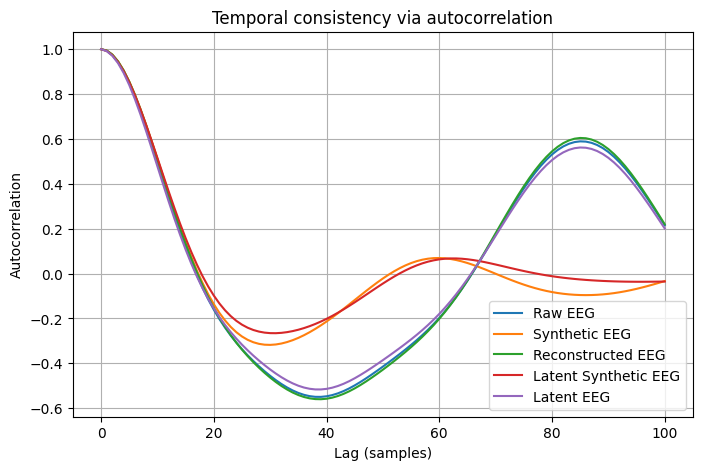

In [45]:
max_lag = 100

acf_synt   = synthetic_eeg_acf(G,R,device,max_lag)
acf_raw    = raw_eeg_acf(dataloader, max_lag)
acf_recon  = reconstructed_eeg_acf(E, R, dataloader, device, max_lag)
acf_synt_lat = latent_synthetic_eeg_acf(G,device,max_lag)
acf_lat = latent_acf(E, dataloader, device, max_lag)

plt.figure(figsize=(8, 5))
plt.plot(acf_raw, label="Raw EEG")
plt.plot(acf_synt, label="Synthetic EEG")
plt.plot(acf_recon, label="Reconstructed EEG")
plt.plot(acf_synt_lat, label="Latent Synthetic EEG")
plt.plot(acf_lat, label="Latent EEG")

plt.xlabel("Lag (samples)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.title("Temporal consistency via autocorrelation")
plt.grid(True)
plt.show()

In [46]:
def compute_psd(x):
    # x: (N, T)

    X = torch.fft.rfft(x, dim=-1)
    psd = (X.abs() ** 2) / x.shape[-1]

    return psd

In [47]:
@torch.no_grad()
def latent_psd(embedder, dataloader, device):
    embedder.eval()
    psds = []

    for x in dataloader:
        x = x.to(device)

        z = embedder(x)  # (B, T, D)

        B, T, D = z.shape

        # reshape so each latent dimension becomes a signal
        z = z.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(z)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)


In [48]:
@torch.no_grad()
def real_psd(dataloader, device):
    psds = []

    for x in dataloader:
        x = x.to(device)


        B, T, D = x.shape

        # reshape so each latent dimension becomes a signal
        x = x.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(x)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)

In [49]:
@torch.no_grad()
def recon_psd(embedder, recovery, dataloader, device):
    embedder.eval()
    recovery.eval()
    psds = []

    for x in dataloader:
        x = x.to(device)

        z = embedder(x)  # (B, T, D)
        z = recovery(z)

        B, T, D = z.shape

        # reshape so each latent dimension becomes a signal
        z = z.permute(0, 2, 1).reshape(B * D, T)

        psd = compute_psd(z)  # expected shape: (B*D, F)
        

        psds.append(psd)

    psds = torch.cat(psds)

    return psds.mean(dim=0)

In [50]:
@torch.no_grad()
def recon_syn_psd(embedder, recovery, generator, device):
    embedder.eval()
    recovery.eval()
    generator.eval()

    psds = []

    B = BATCH_SIZE
    T = WINDOW_SIZE
    z_dim = LATENT_DIM + 4

    # Generate synthetic batch
    Z = torch.randn(B, T, z_dim, device=device)
    H_fake = generator(Z)          # (B, T, D_latent)
    X_fake = recovery(H_fake)      # (B, T, D_data)

    B, T, D = X_fake.shape

    # Match real pipeline: treat each dimension as a signal
    X_fake = X_fake.permute(0, 2, 1).reshape(B * D, T)

    # Compute PSD
    psd = compute_psd(X_fake)      # (B*D, F)

    psds.append(psd)

    # Aggregate
    psds = torch.cat(psds)
    return psds.mean(dim=0)

In [51]:
realPSD = real_psd(dataloader, device)
reconPSD = recon_psd(E, R, dataloader, device)
synPSD = recon_syn_psd(E,R,G,device)

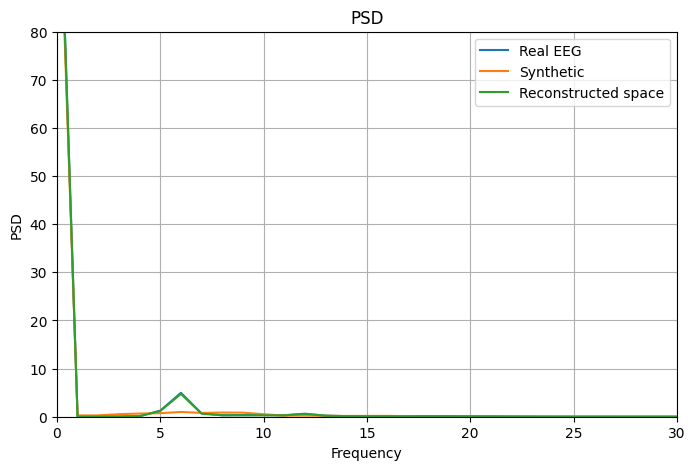

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(realPSD.cpu(), label="Real EEG")
plt.plot(synPSD.cpu(), label="Synthetic")
plt.plot(reconPSD.cpu(), label="Reconstructed space")

plt.axis([0, 30, 0, 80])
plt.xlabel("Frequency")
plt.ylabel("PSD")
plt.legend()
plt.title("PSD")
plt.grid(True)
plt.show()
